# Test MCTS

In [1]:
import cma

## Load data

In Total  41  ports are plotted


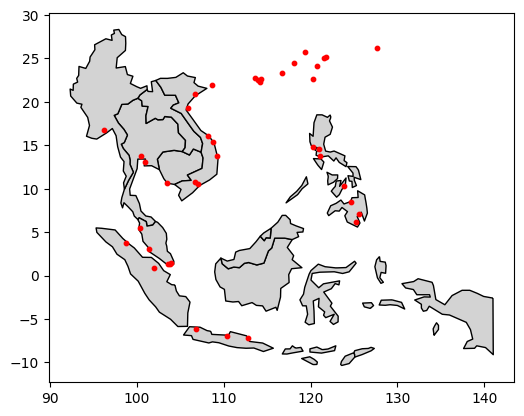

In [ ]:
# vessel data
vessels_pool = cma.read_vessel_class_data()
# port data
_, portpool = cma.read_port_data()
asia_pacific_countries = [
	#'China','Taiwan', 'Japan', 'South Korea',
	'Vietnam', 'Myanmar', 'Laos', 'Thailand', 'Cambodia',
	'Indonesia', 'Philippines', 'Malaysia', 'Singapore', 'Brunei', 'Timor-Leste',
	#'Pakistan', 'India', 'Bangladesh', 'Sri Lanka', 'Nepal','Maldives',
	#'Australia', 'Papua New Guinea', 'New Zealand', 'Solomon Islands',
	#'Vanuatu', 'Samoa', 'Tonga', 'Tuvalu', 'Nauru', 'Palau', 'Marshall Islands','Kiribati' #, 'Fiji'
]
_, ax, portpool_selected = portpool.plot(asia_pacific_countries, plot_port_id = False)

In [3]:
# lines data
current_lines, _ = cma.read_current_line_data(portpool_selected)
# sailing distance data
dist_mat = cma.read_sailing_distance_data(portpool_selected)
# demand data
demands_dict, total_weekly_demand_mat = cma.read_demand_data(portpool_selected)

/Users/linsheng/Documents/GitHub/nus_cma_project/src/cma/data_reader.py:129: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(str(file))  # read first table


## Create Root Service graph

In [4]:
portgraph = cma.PortGraph(portpool_selected, dist_mat, total_weekly_demand_mat)
servicegraph = cma.ServiceGraph(current_lines)

## Run MCTS

In [5]:
tree = cma.MonteCarloTree(
    service_graph=servicegraph,
    portgraph=portgraph,
    vesselpool=vessels_pool,
    discount_fac=0.5, max_depth=5, c_param=0.5)

In [6]:
tree.run(10)

call rollout
call expand
call rollout
call expand
call rollout
call expand
call rollout
call expand
call rollout
call expand
